# OpenET vs NLDAS Noah ET Harmonization — Iowa 2015–2024

## Overview

This notebook computes the **human ET contribution** (ΔET) for Iowa agricultural land
by differencing two independent ET estimates:

$$\Delta ET = \text{OpenET} - \text{NLDAS Noah ET}$$

- **OpenET** captures *total* actual evapotranspiration including irrigation water.
- **NLDAS Noah** models what ET *would be* under atmospheric forcing alone (no irrigation).
- **ΔET > 0** indicates more ET than the land surface model predicts → likely irrigation or other human water addition.
- **ΔET < 0** indicates less ET than expected → drought stress, crop failure, or fallow land.

### Irrigation confidence thresholds

Based on the known error margins of these two ET data products:
- **ΔET > +20 mm/month** = **High-confidence irrigation** (signal exceeds measurement uncertainty)
- **ΔET ≤ +20 mm/month** = **Low-confidence or no irrigation** (within measurement noise)

### Data sources

| Dataset | Source | Resolution | Variable |
|---|---|---|---|
| OpenET | GEE `projects/openet/assets/...` | 0.125° NLDAS grid | mm/month actual ET |
| NLDAS Noah | NASA Earthdata DOI 10.5067/WB224IA3PVOJ | 0.125° | `Evap` mm/month |
| CDL | USDA NASS via GEE | Resampled to 0.125° | Cropland fraction |

### Pipeline summary

1. Load and verify spatial alignment of NLDAS, OpenET, and CDL
2. Build annual binary cropland masks from CDL (fraction > 50%)
3. For each of the 120 months (2015–2024): align grids, apply mask, compute ΔET
4. Save masked GeoTIFFs and a summary CSV
5. Visualize time series, seasonal cycle, spatial maps, and annual heatmap

**Output:** `data/processed/ET_delta/ET_delta_YYYYMM_Iowa_cropland.tif`

## 1. Setup and Library Imports

Import all required libraries. The `matplotlib` backend is set automatically:
- Headless HPC nodes (SLURM): uses `Agg` (non-interactive, saves to file)
- VS Code / Jupyter: uses the interactive inline backend

In [ ]:
import sys, os
print(f'Python: {sys.executable}')

import matplotlib
# On HPC nodes without a display, force the non-interactive Agg backend so
# plt.savefig() works. In VS Code leave the backend as the default inline renderer.
_is_hpc = os.environ.get('SLURM_JOB_ID') or os.environ.get('SIF_ROOT')
if _is_hpc:
    matplotlib.use('Agg')

import xarray as xr
import rioxarray as rxr
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject, calculate_default_transform
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print(f'matplotlib backend: {matplotlib.get_backend()}')
print('All libraries loaded successfully.')

## 2. Paths and Configuration

Set all file paths and analysis parameters here. A single `YEARS` list controls
the full 10-year study period. All downstream cells reference these variables,
so changing the years here is the only edit needed to adjust the study period.

### CDL year fallback
CDL data is annual. If a particular year's CDL file is not yet on disk (e.g., 2015–2018
have not been downloaded from Google Drive yet after the GEE export), the code will
fall back to the nearest available year's CDL. This allows partial analyses while
data is being staged, but the fallback is logged clearly so you can track which
years are using a surrogate mask.

In [ ]:
# ─── Project root ─────────────────────────────────────────────────────────────
# SIF_ROOT env var is set by SLURM scripts on the HPC. When running interactively
# in VS Code, fall back to navigating 3 levels up from this notebook's location.
_root_env    = os.environ.get('SIF_ROOT')
project_root = Path(_root_env) if _root_env else Path('../../..').resolve()
print(f'Project root: {project_root}')

# ─── Input data directories ───────────────────────────────────────────────────
nldas_dir     = project_root / 'data' / 'raw' / 'NLDAS_Noah'
openet_dir    = project_root / 'data' / 'raw' / 'OpenET'
cdl_dir       = project_root / 'data' / 'raw' / 'Cornbelt_annual_CDL'
iowa_boundary = project_root / 'data' / 'aoi' / 'iowa.geojson'

# ─── Output directories ───────────────────────────────────────────────────────
output_dir  = project_root / 'data' / 'processed' / 'ET_delta'
mask_dir    = project_root / 'data' / 'processed' / 'cropland_masks'
figures_dir = project_root / 'figures' / 'et_delta'

# Create output dirs if they don't exist
output_dir.mkdir(parents=True, exist_ok=True)
mask_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# ─── Study period ─────────────────────────────────────────────────────────────
# 10-year period aligned to Drought Monitor availability (2015-01) and NLDAS
# data that has been or will be downloaded. Change these to adjust the range.
YEARS  = list(range(2015, 2025))   # 2015–2024
MONTHS = list(range(1, 13))        # All 12 months

# ─── Cropland mask parameters ─────────────────────────────────────────────────
# CDL codes < 100 are crop types; ≥ 100 are non-agricultural land covers.
CROPLAND_MAX_CODE          = 100
# An NLDAS pixel is considered "cropland" if at least this fraction of its area
# (at CDL's ~500m native resolution) is classified as a crop code.
CROPLAND_FRACTION_THRESHOLD = 0.5

# ─── Verify input files ───────────────────────────────────────────────────────
nldas_files  = sorted(nldas_dir.glob('NLDAS_NOAH0125_M.A*.nc'))
openet_files = sorted(openet_dir.glob('OpenET_Iowa_*.tif'))
cdl_files    = sorted(cdl_dir.glob('Cornbelt_annual_CDL_cropland_*.tif'))

n_expected = len(YEARS) * 12

print(f'NLDAS Noah files:  {len(nldas_files)} (expected {n_expected})')
print(f'OpenET files:      {len(openet_files)} (expected {n_expected})')
print(f'CDL files on disk: {len(cdl_files)} ({[f.stem.split("_")[-1][:4] for f in cdl_files]})')
print(f'Output directory:  {output_dir}')
print(f'Mask directory:    {mask_dir}')
print()
if len(nldas_files) < n_expected:
    print(f'⚠  NLDAS: {n_expected - len(nldas_files)} files missing — run nldas_et_download.ipynb')
if len(openet_files) < n_expected:
    print(f'⚠  OpenET: {n_expected - len(openet_files)} files missing — run openet_download.py')
if len(cdl_files) < len(YEARS):
    cdl_years = {int(f.stem.split("_")[-1][:4]) for f in cdl_files}
    missing   = sorted(set(YEARS) - cdl_years)
    print(f'⚠  CDL: missing years {missing} — run download_gee_cdl.py and copy from Drive')

## 3. Verify Spatial Alignment

Confirm that NLDAS, OpenET, and CDL all share EPSG:4326 and check their spatial
resolutions. The 0.125° NLDAS grid is our reference; OpenET is already on this
same grid (aligned during download via the GEE reference asset), and CDL (~0.005°)
will be resampled to it in the next section.

This cell is purely diagnostic — no data is processed here.

In [ ]:
iowa_gdf = gpd.read_file(iowa_boundary)

# ── Inspect NLDAS grid ────────────────────────────────────────────────────────
ds_nldas = xr.open_dataset(nldas_files[0])
print('NLDAS Noah:')
print(f'  lon: {float(ds_nldas.lon[0]):.4f} to {float(ds_nldas.lon[-1]):.4f}',
      f'  step = {float(ds_nldas.lon[1]-ds_nldas.lon[0]):.4f}°')
print(f'  lat: {float(ds_nldas.lat[0]):.4f} to {float(ds_nldas.lat[-1]):.4f}',
      f'  step = {float(ds_nldas.lat[1]-ds_nldas.lat[0]):.4f}°')
ds_nldas.close()

# ── Inspect OpenET ────────────────────────────────────────────────────────────
with rasterio.open(openet_files[0]) as src:
    openet_transform = src.transform
    openet_crs       = src.crs
    openet_shape     = (src.height, src.width)
    print(f'\nOpenET:')
    print(f'  CRS: {openet_crs}')
    print(f'  Origin: ({openet_transform.c:.4f}, {openet_transform.f:.4f})')
    print(f'  Resolution: {openet_transform.a:.4f}°')
    print(f'  Shape: {openet_shape[0]} rows x {openet_shape[1]} cols')

# ── Inspect CDL ───────────────────────────────────────────────────────────────
with rasterio.open(cdl_files[0]) as src:
    print(f'\nCDL:')
    print(f'  CRS: {src.crs}')
    print(f'  Resolution: {src.res[0]:.6f}° (~{src.res[0]*111:.1f} km)')
    print(f'  Shape: {src.height} rows x {src.width} cols')
    print(f'  File: {cdl_files[0].name}')
    print(f'  → Will be resampled to 0.125° using Resampling.average (crop fraction per pixel)')

print('\n✓ All datasets confirmed EPSG:4326 — ready for alignment.')

## 3.1 Raw Data Coverage Check

Before computing deltas, visually confirm that both OpenET and NLDAS have full Iowa
coverage without tiling gaps. We spot-check 10 evenly-spaced months from each dataset.

- **OpenET**: all 53×25 Iowa pixels should show spatially varying values
- **NLDAS**: stored with latitudes ascending (south→north); we flip vertically for display

A tight p2–p98 percentile colorscale is used so subtle spatial gradients are visible
even in low-ET winter months.

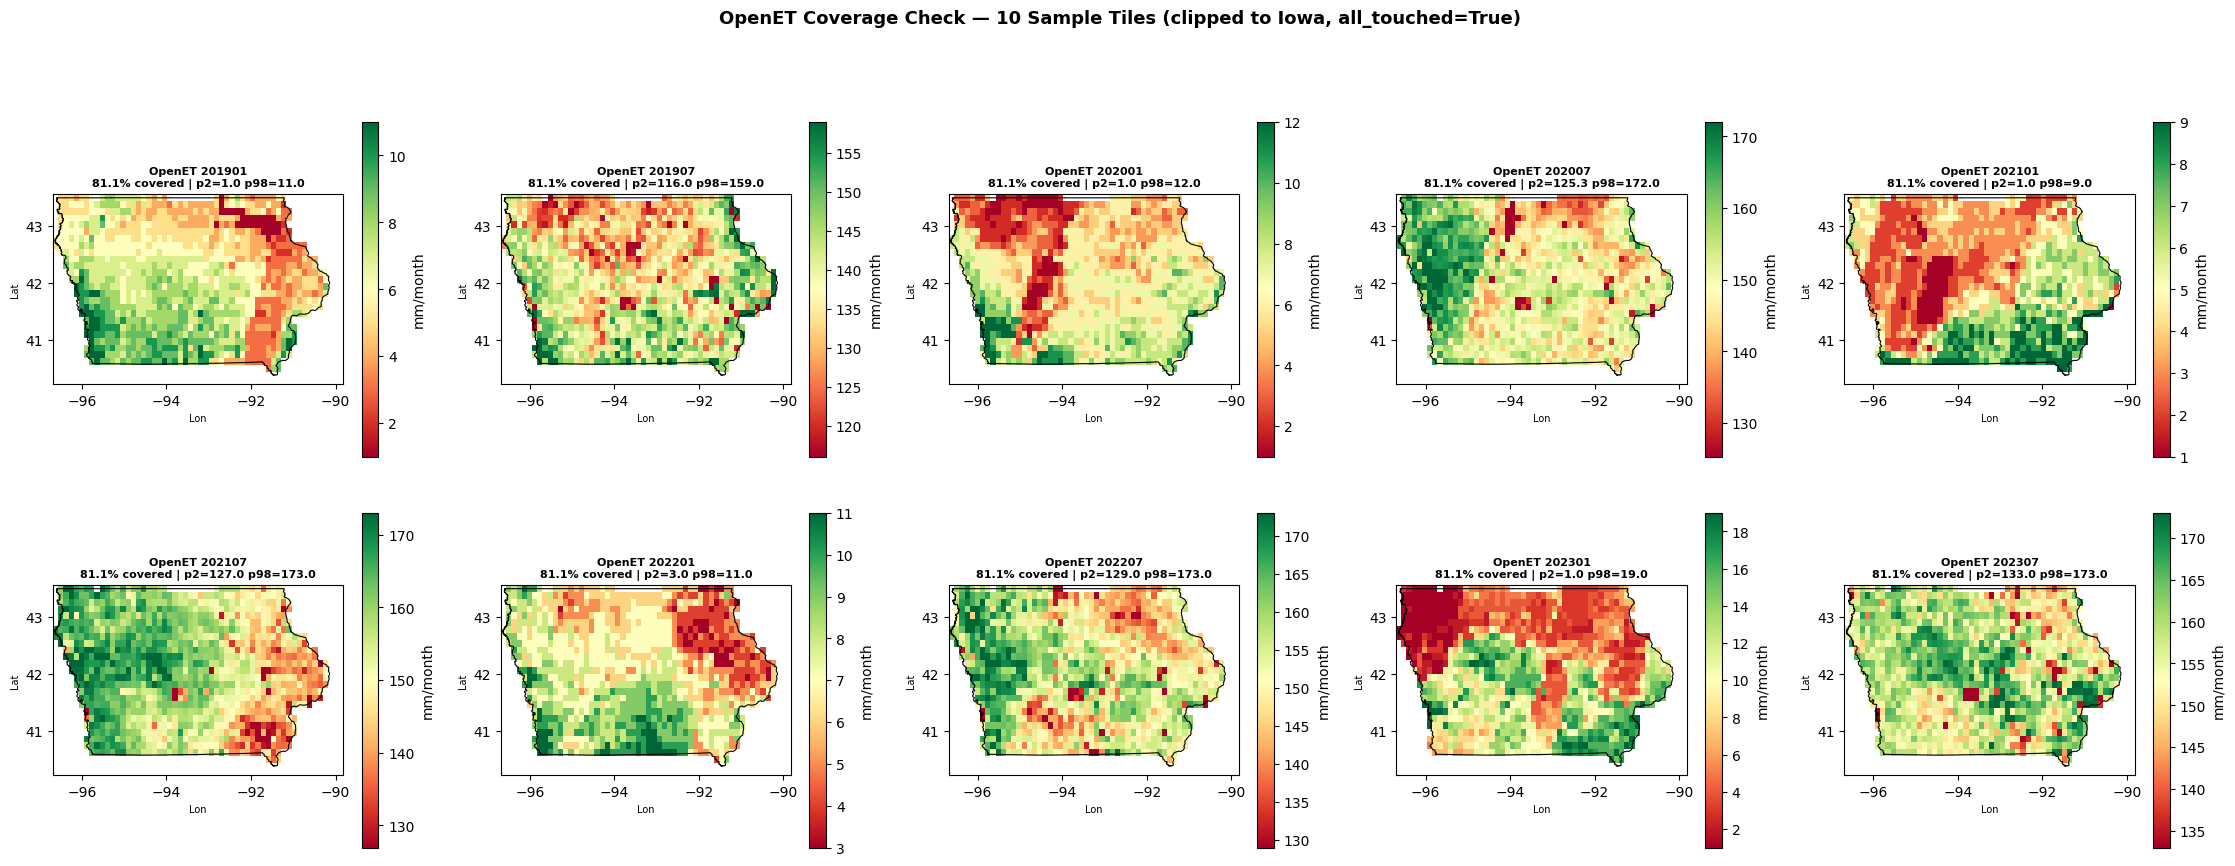

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/et_delta/openet_coverage_check.png


In [4]:
# ── OpenET: 10 tile coverage check ───────────────────────────────────────────
if len(openet_files) == 0:
    print('WARNING: No OpenET files found — skipping coverage check.')
else:
    step   = max(1, len(openet_files) // 10)
    sample = openet_files[::step][:10]

    ncols = 5
    nrows = (len(sample) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 4.5))
    axes = np.array(axes).flatten()

    for i, fpath in enumerate(sample):
        ax = axes[i]

        # Clip to Iowa with all_touched=True so border pixels are included
        da = rxr.open_rasterio(fpath, masked=True).squeeze()
        da_iowa = da.rio.clip(iowa_gdf.geometry, iowa_gdf.crs,
                              all_touched=True, drop=True)
        arr = da_iowa.values.astype(float)
        arr[arr < -9000] = np.nan

        valid = arr[~np.isnan(arr)]
        if len(valid) == 0:
            ax.set_title(f'{fpath.stem}\nNO VALID DATA', color='red')
            ax.set_visible(True)
            continue

        # Tight percentile range highlights small spatial variations
        vmin, vmax = np.nanpercentile(valid, [2, 98])
        # Guard against flat months (e.g. winter, all near zero)
        if vmax - vmin < 1:
            vmin, vmax = vmin - 0.5, vmax + 0.5

        extent = [float(da_iowa.x.min()), float(da_iowa.x.max()),
                  float(da_iowa.y.min()), float(da_iowa.y.max())]

        im = ax.imshow(arr, extent=extent, origin='upper',
                       cmap='RdYlGn', vmin=vmin, vmax=vmax, aspect='auto')
        iowa_gdf.boundary.plot(ax=ax, color='black', linewidth=0.8)
        plt.colorbar(im, ax=ax, shrink=0.75, label='mm/month')

        yyyymm   = fpath.stem.replace('OpenET_Iowa_', '')
        n_nan    = np.isnan(arr).sum()
        coverage = 100 * (1 - n_nan / arr.size)
        ax.set_title(f'OpenET {yyyymm}\n{coverage:.1f}% covered | p2={vmin:.1f} p98={vmax:.1f}',
                     fontsize=8, fontweight='bold')
        ax.set_xlabel('Lon', fontsize=7)
        ax.set_ylabel('Lat', fontsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('OpenET Coverage Check — 10 Sample Tiles (clipped to Iowa, all_touched=True)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(figures_dir / 'openet_coverage_check.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {figures_dir}/openet_coverage_check.png')

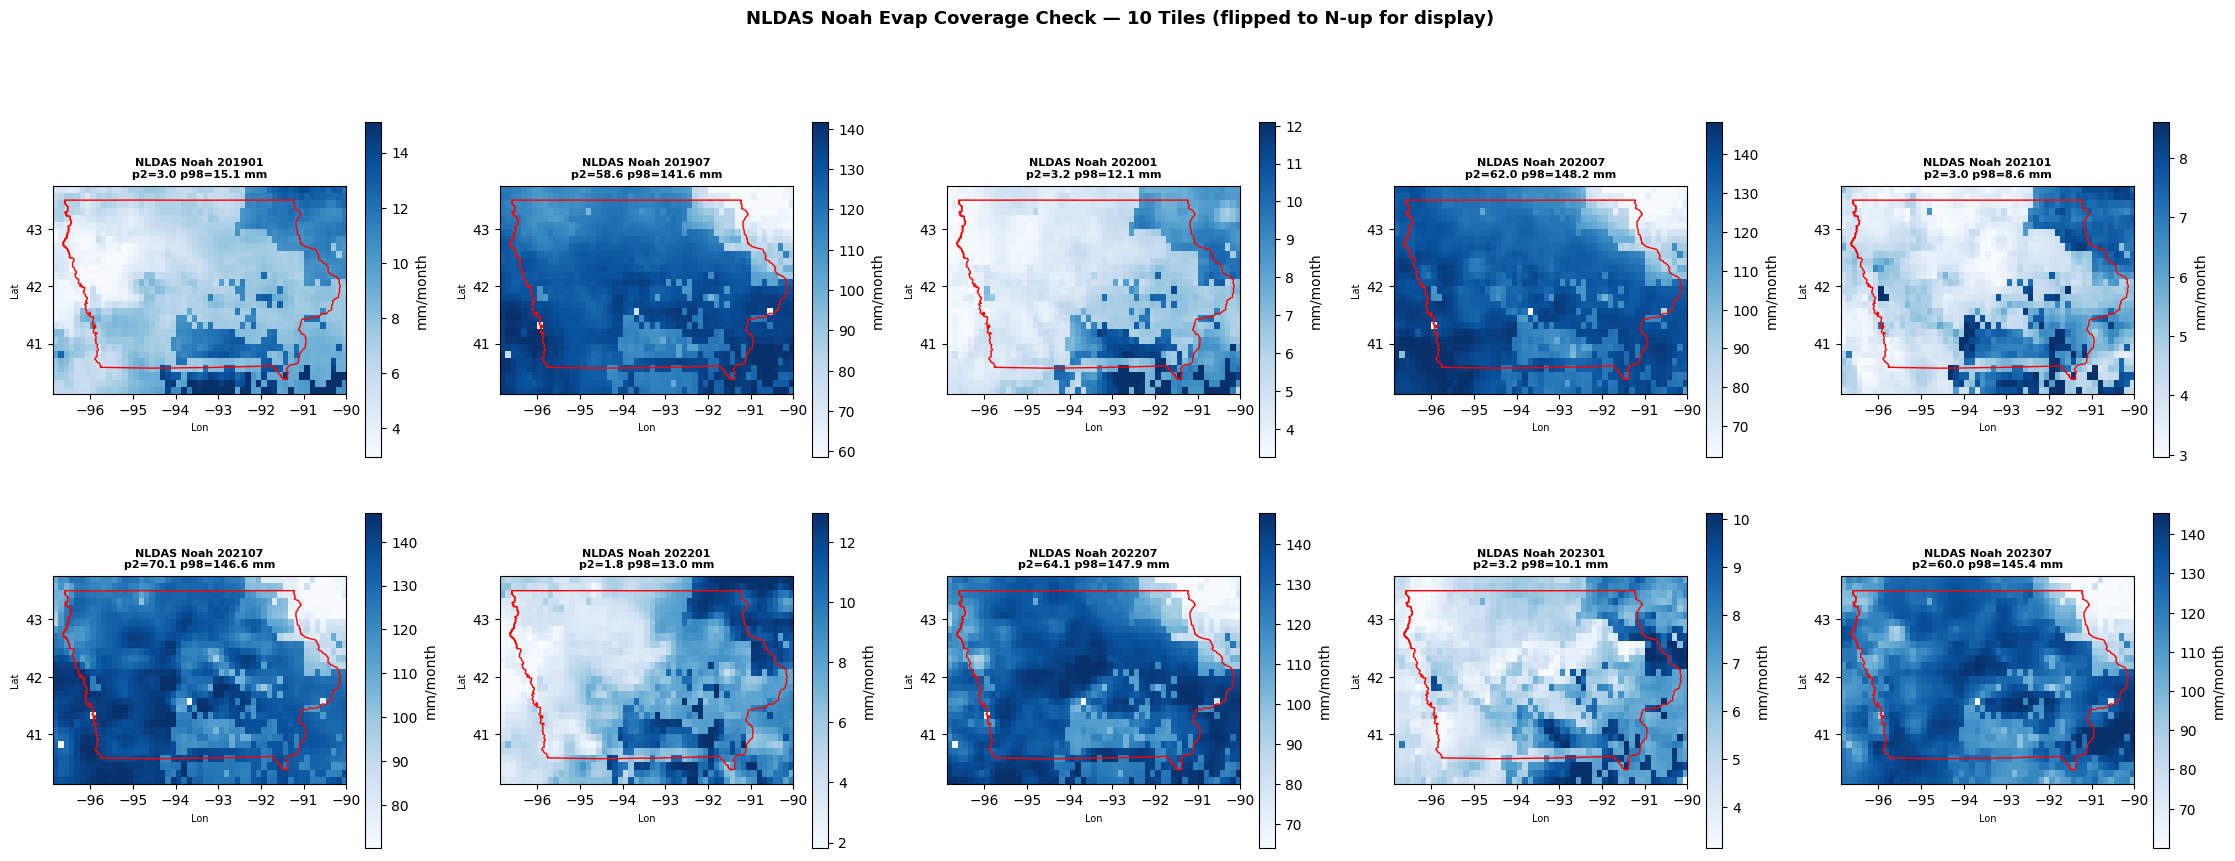

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/et_delta/nldas_coverage_check.png


In [5]:
# ── NLDAS: 10 tile coverage check with orientation fix ───────────────────────
# NLDAS stores latitudes in ascending order (south→north, lat[0]=25°).
# Displayed with origin='upper' this puts south at the top — upside down.
# We flip the array vertically before plotting so north is up.

if len(nldas_files) == 0:
    print('WARNING: No NLDAS files found — skipping coverage check.')
else:
    step   = max(1, len(nldas_files) // 10)
    sample = nldas_files[::step][:10]

    iowa_bb = iowa_gdf.total_bounds  # [minx, miny, maxx, maxy]

    ncols = 5
    nrows = (len(sample) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 4.5))
    axes = np.array(axes).flatten()

    for i, fpath in enumerate(sample):
        ax = axes[i]
        ds  = xr.open_dataset(fpath)
        et  = ds['Evap'].squeeze()

        lats = et.lat.values   # ascending: 25.06 → 52.94
        lons = et.lon.values
        arr  = et.values.astype(float)
        arr[arr <= -9000] = np.nan
        ds.close()

        # Subset to Iowa bounding box (with small buffer)
        lat_mask = (lats >= iowa_bb[1] - 0.2) & (lats <= iowa_bb[3] + 0.2)
        lon_mask = (lons >= iowa_bb[0] - 0.2) & (lons <= iowa_bb[2] + 0.2)
        arr_iowa  = arr[np.ix_(lat_mask, lon_mask)]
        lats_iowa = lats[lat_mask]
        lons_iowa = lons[lon_mask]

        # Flip to north-up: reverse row order so lat[0] (south) is at the bottom
        arr_iowa  = arr_iowa[::-1, :]
        lats_iowa = lats_iowa[::-1]

        valid = arr_iowa[~np.isnan(arr_iowa)]
        if len(valid) == 0:
            ax.set_title(f'{fpath.stem}\nNO VALID DATA', color='red')
            continue

        vmin, vmax = np.nanpercentile(valid, [2, 98])
        if vmax - vmin < 0.5:
            vmin, vmax = vmin - 0.25, vmax + 0.25

        # extent for imshow: [left, right, bottom, top]
        # lats_iowa[0] is now north (after flip), lats_iowa[-1] is south
        extent = [lons_iowa.min() - 0.0625, lons_iowa.max() + 0.0625,
                  lats_iowa[-1] - 0.0625,   lats_iowa[0]  + 0.0625]

        im = ax.imshow(arr_iowa, extent=extent, origin='upper',
                       cmap='Blues', vmin=vmin, vmax=vmax, aspect='auto')
        iowa_gdf.boundary.plot(ax=ax, color='red', linewidth=1.0)
        plt.colorbar(im, ax=ax, shrink=0.75, label='mm/month')

        yyyymm = fpath.name.split('.A')[1][:6] if '.A' in fpath.name else fpath.stem
        ax.set_title(f'NLDAS Noah {yyyymm}\np2={vmin:.1f} p98={vmax:.1f} mm',
                     fontsize=8, fontweight='bold')
        ax.set_xlabel('Lon', fontsize=7)
        ax.set_ylabel('Lat', fontsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('NLDAS Noah Evap Coverage Check — 10 Tiles (flipped to N-up for display)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(figures_dir / 'nldas_coverage_check.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {figures_dir}/nldas_coverage_check.png')

In [ ]:
# =============================================================================
# 3.2  Year-by-Year July Check — OpenET and NLDAS Noah
# One panel per year for each dataset. Confirms full 2015–2024 coverage and
# plausible Iowa ET patterns. Red cell = file missing on disk.
# Change CHECK_MONTH to spot-check any other month.
# =============================================================================

CHECK_MONTH = 7   # July — peak growing season for Iowa row crops

iowa_bb = iowa_gdf.total_bounds   # [minx, miny, maxx, maxy]
n_years = len(YEARS)

fig, axes = plt.subplots(2, n_years, figsize=(n_years * 2.8, 6.5),
                          gridspec_kw={'hspace': 0.05, 'wspace': 0.05})

for col, year in enumerate(YEARS):
    yyyymm = f'{year}{CHECK_MONTH:02d}'

    # ── Row 0: OpenET ─────────────────────────────────────────────────────────
    ax    = axes[0, col]
    fpath = openet_dir / f'OpenET_Iowa_{yyyymm}.tif'
    if fpath.exists():
        da  = rxr.open_rasterio(fpath, masked=True).squeeze()
        da  = da.rio.clip(iowa_gdf.geometry, iowa_gdf.crs, all_touched=True, drop=True)
        arr = da.values.astype(float); arr[arr < -9000] = np.nan
        valid = arr[~np.isnan(arr)]
        vmin_v, vmax_v = np.nanpercentile(valid, [5, 95]) if len(valid) else (0, 100)
        ax.imshow(arr,
                  extent=[float(da.x.min()), float(da.x.max()),
                          float(da.y.min()), float(da.y.max())],
                  origin='upper', cmap='YlGn', vmin=vmin_v, vmax=vmax_v, aspect='auto')
        iowa_gdf.boundary.plot(ax=ax, color='black', linewidth=0.7)
        ax.set_title(f'{year}\n{np.nanmean(arr):.0f} mm', fontsize=8, fontweight='bold')
    else:
        ax.set_facecolor('#ffcccc')
        ax.text(0.5, 0.5, f'{year}\nMISSING', transform=ax.transAxes,
                ha='center', va='center', color='red', fontsize=8, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    if col == 0:
        ax.set_ylabel('OpenET', fontsize=9, fontweight='bold')

    # ── Row 1: NLDAS Noah ─────────────────────────────────────────────────────
    ax    = axes[1, col]
    fpath = nldas_dir / f'NLDAS_NOAH0125_M.A{yyyymm}.020.nc'
    if fpath.exists():
        ds  = xr.open_dataset(fpath)
        et  = ds['Evap'].squeeze()
        if float(et.lat[0]) < float(et.lat[-1]):
            et = et.isel(lat=slice(None, None, -1))
        lats = et.lat.values; lons = et.lon.values
        arr  = et.values.astype(float); arr[arr <= -9000] = np.nan
        ds.close()
        lat_m = (lats >= iowa_bb[1] - 0.2) & (lats <= iowa_bb[3] + 0.2)
        lon_m = (lons >= iowa_bb[0] - 0.2) & (lons <= iowa_bb[2] + 0.2)
        sub   = arr[np.ix_(lat_m, lon_m)]
        lsub  = lats[lat_m]; lsub2 = lons[lon_m]
        valid = sub[~np.isnan(sub)]
        vmin_v, vmax_v = np.nanpercentile(valid, [5, 95]) if len(valid) else (0, 100)
        ax.imshow(sub,
                  extent=[lsub2.min(), lsub2.max(), lsub.min(), lsub.max()],
                  origin='lower', cmap='Blues', vmin=vmin_v, vmax=vmax_v, aspect='auto')
        iowa_gdf.boundary.plot(ax=ax, color='red', linewidth=0.7)
        ax.set_title(f'{np.nanmean(sub):.0f} mm', fontsize=8)
    else:
        ax.set_facecolor('#ffcccc')
        ax.text(0.5, 0.5, 'MISSING', transform=ax.transAxes,
                ha='center', va='center', color='red', fontsize=8, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    if col == 0:
        ax.set_ylabel('NLDAS Noah', fontsize=9, fontweight='bold')

plt.suptitle(
    f'Year-by-Year July Check — OpenET (green) & NLDAS Noah (blue)  |  {YEARS[0]}–{YEARS[-1]}\n'
    f'Panel title = year + Iowa-mean mm/month; red = file missing',
    fontsize=11, fontweight='bold', y=1.02)
plt.savefig(figures_dir / 'year_by_year_july_check.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {figures_dir}/year_by_year_july_check.png')

## 4. Build NLDAS Reference Grid and Annual Cropland Masks

### 4.1 Reference grid

The 0.125° NLDAS Iowa grid is defined by the first NLDAS file. This transform and shape
are used as the target for all reprojection operations throughout the notebook.

### 4.2 Cropland masks

For each year in the study period we:
1. Load the USDA NASS CDL GeoTIFF (crop codes at ~500m resolution)
2. Create a binary layer: `1 = cropland` (CDL code < 100), `0 = non-crop`
3. Resample to 0.125° using `Resampling.average` → gives the **cropland fraction** per pixel
4. Apply threshold (`≥ 0.5`) → binary cropland mask for that year

Masks are cached to disk so CDL resampling only runs once per year.

**CDL year fallback:** If a CDL file is missing for a target year (e.g. 2015–2018 have not
been downloaded yet), the code uses the nearest available year's CDL. The mask will still
correctly capture the Iowa agricultural footprint; crop rotation changes between years have
a minor effect at 0.125° resolution.

In [ ]:
import rasterio.transform

def build_cropland_mask(cdl_path, target_transform, target_shape,
                        target_crs='EPSG:4326',
                        threshold=0.5, cropland_max_code=100):
    """
    Resample annual CDL to the NLDAS 0.125° grid and return a binary cropland mask.

    Process:
      1. Read CDL (integer crop codes, ~500m resolution)
      2. Convert to binary: 1 = cropland (code < cropland_max_code), 0 = non-crop
      3. True nodata pixels → NaN so they don't dilute the resampled fraction
      4. Reproject with Resampling.average → cropland fraction per NLDAS pixel
      5. Threshold → boolean mask

    Parameters
    ----------
    cdl_path : Path
        Annual CDL GeoTIFF path.
    target_transform : Affine
        NLDAS Iowa affine transform (from_origin, north-up).
    target_shape : tuple (rows, cols)
        Shape of the NLDAS Iowa grid.
    threshold : float
        Minimum cropland fraction to classify pixel as cropland (default 0.5).
    cropland_max_code : int
        CDL codes strictly below this are considered crops (default 100).

    Returns
    -------
    mask : np.ndarray (bool), shape = target_shape
        True where the NLDAS pixel is ≥ threshold cropland fraction.
    crop_fraction : np.ndarray (float32), shape = target_shape
        Raw cropland fraction (0–1) per NLDAS pixel before thresholding.
    """
    with rasterio.open(cdl_path) as src:
        cdl_data      = src.read(1).astype(np.float32)
        cdl_transform = src.transform
        cdl_crs       = src.crs

    # Binary conversion: crop codes 1-99 → 1.0; everything else → 0.0
    binary = np.where((cdl_data > 0) & (cdl_data < cropland_max_code), 1.0, 0.0)
    # True nodata (code == 0) → NaN so it doesn't count against the fraction
    binary[cdl_data == 0] = np.nan

    # Reproject to NLDAS grid — average resampling gives cropland fraction per pixel
    crop_fraction = np.empty(target_shape, dtype=np.float32)
    reproject(
        source      = binary,
        destination = crop_fraction,
        src_transform = cdl_transform,
        src_crs       = cdl_crs,
        src_nodata    = np.nan,
        dst_transform = target_transform,
        dst_crs       = target_crs,
        resampling    = Resampling.average,
    )

    mask = crop_fraction >= threshold
    return mask, crop_fraction


# ─── Build the NLDAS Iowa reference grid ─────────────────────────────────────
# Use the first NLDAS file to extract the lon/lat coordinates
ds_ref     = xr.open_dataset(nldas_files[0])
nldas_lons = ds_ref.lon.values   # 1-D array, ascending
nldas_lats = ds_ref.lat.values   # 1-D array, ascending (25° → 53°)
ds_ref.close()

nldas_res = 0.125  # degrees (0.125° = ~14 km)

# from_origin expects the top-left (northwest) corner, so use the last lat element
# (which is the northernmost row since lats are ascending in NLDAS)
nldas_transform = rasterio.transform.from_origin(
    west  = nldas_lons[0]  - nldas_res / 2,
    north = nldas_lats[-1] + nldas_res / 2,
    xsize = nldas_res,
    ysize = nldas_res,
)
nldas_shape = (len(nldas_lats), len(nldas_lons))

print(f'NLDAS reference grid:')
print(f'  Shape:     {nldas_shape[0]} rows x {nldas_shape[1]} cols')
print(f'  Transform: {nldas_transform}')

# ─── Determine available CDL years on disk ────────────────────────────────────
cdl_years_on_disk = sorted({
    int(f.stem.split('_')[-1][:4]) for f in cdl_files
})
print(f'\nCDL years on disk: {cdl_years_on_disk}')

def get_cdl_path(year):
    """
    Return the CDL path for `year`, falling back to the nearest available year
    if the exact year is not on disk. Logs a warning when fallback is used.
    """
    exact = cdl_dir / f'Cornbelt_annual_CDL_cropland_{year}-01.tif'
    if exact.exists():
        return exact, year

    # Find nearest year with an available CDL file
    if not cdl_years_on_disk:
        return None, None
    nearest = min(cdl_years_on_disk, key=lambda y: abs(y - year))
    fallback = cdl_dir / f'Cornbelt_annual_CDL_cropland_{nearest}-01.tif'
    print(f'  ⚠  CDL {year} not found — using {nearest} as fallback')
    return fallback, nearest


# ─── Build or load annual cropland masks (cached as GeoTIFFs) ────────────────
cropland_masks    = {}   # year → boolean np.ndarray (iowa grid)
cropland_fraction = {}   # year → float np.ndarray (iowa grid)

for year in YEARS:
    frac_path = mask_dir / f'cropland_fraction_{year}_nldas.tif'

    if frac_path.exists():
        # Load from disk cache — avoids re-running CDL resampling
        with rasterio.open(frac_path) as src:
            frac = src.read(1)
        mask         = frac >= CROPLAND_FRACTION_THRESHOLD
        source_label = 'cache'
    else:
        cdl_path, source_year = get_cdl_path(year)
        if cdl_path is None:
            print(f'  SKIP {year}: no CDL data available')
            continue

        mask, frac = build_cropland_mask(
            cdl_path, nldas_transform, nldas_shape,
            threshold=CROPLAND_FRACTION_THRESHOLD,
        )

        # Cache the cropland fraction (mask is always derived by re-applying threshold)
        with rasterio.open(
            frac_path, 'w', driver='GTiff',
            height=nldas_shape[0], width=nldas_shape[1],
            count=1, dtype=np.float32,
            crs='EPSG:4326', transform=nldas_transform
        ) as dst:
            dst.write(frac, 1)

        source_label = f'built from CDL {source_year}'

    cropland_masks[year]    = mask
    cropland_fraction[year] = frac

    pct = mask.sum() / mask.size * 100
    print(f'  {year} [{source_label}]: '
          f'{mask.sum()} cropland pixels ({pct:.1f}%)  '
          f'| mean fraction = {np.nanmean(frac):.2f}')

print('\nCropland masks ready.')

## 4.3 Visualize Annual Cropland Masks

Plot the CDL-derived cropland fraction for each year. Color = fraction of each
0.125° pixel classified as cropland in the CDL. Pixels above the 0.5 threshold
(included in analysis) are in the upper half of the colorscale.

Look for consistency across years — the Iowa agricultural footprint should be stable,
with minor changes from crop rotation and land-use change.

In [ ]:
years_with_masks = [y for y in YEARS if y in cropland_fraction]
n_yrs = len(years_with_masks)

# Use 2 rows if there are more than 6 years, otherwise 1 row
n_cols = min(n_yrs, 6)
n_rows = (n_yrs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 4))
axes = np.array(axes).flatten()

# Compute the spatial extent of the NLDAS Iowa grid for imshow
west  = nldas_transform.c
north = nldas_transform.f
east  = west  + nldas_transform.a * nldas_shape[1]
south = north + nldas_transform.e * nldas_shape[0]   # e is negative → south < north

for ax, year in zip(axes, years_with_masks):
    frac = cropland_fraction[year]
    n_crop = cropland_masks[year].sum()

    # imshow with origin='upper' expects data[0] = northernmost row (which it is,
    # since we built the mask with a north-up transform)
    im = ax.imshow(frac, extent=[west, east, south, north],
                   origin='upper', cmap='YlGn', vmin=0, vmax=1, aspect='auto')
    iowa_gdf.boundary.plot(ax=ax, color='black', linewidth=0.8)
    ax.set_title(f'{year}  ({n_crop} crop px)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Lon', fontsize=8)
    ax.set_ylabel('Lat', fontsize=8)

# Hide unused axes
for ax in axes[len(years_with_masks):]:
    ax.set_visible(False)

# Shared colorbar below all panels
cbar = fig.colorbar(im, ax=axes[:len(years_with_masks)], orientation='horizontal',
                    fraction=0.04, pad=0.15)
cbar.set_label(f'Cropland fraction per 0.125° pixel  |  mask threshold = {CROPLAND_FRACTION_THRESHOLD}',
               fontsize=9)

plt.suptitle(f'Annual CDL Cropland Fraction — Iowa {YEARS[0]}–{YEARS[-1]}\n'
             f'(resampled from ~500m CDL to NLDAS 0.125° grid)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(figures_dir / 'cropland_masks.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {figures_dir}/cropland_masks.png')

## 5. Compute ΔET for All Months

For each of the 120 months (2015–2024) this cell:
1. Loads the NLDAS Noah ET file and flips latitudes to north-up orientation
2. Clips to Iowa using the state boundary (center-based: `all_touched=False`)
3. Loads the OpenET tile and reprojects it to the NLDAS Iowa grid via `Resampling.average`
4. Subtracts NLDAS from OpenET to get ΔET (mm/month)
5. Applies the annual cropland mask (setting non-crop pixels to NaN)
6. Saves the masked delta as a GeoTIFF
7. Records summary statistics to a list for CSV export

**On latitudes:** NLDAS stores lats ascending (south→north, lat[0] = 25°). The cropland
mask and OpenET are both north-up. We flip NLDAS before any spatial operations to maintain
consistent pixel ordering across all datasets.

In [ ]:
records     = []          # summary stats per month → becomes the summary CSV
delta_grids = {}          # (year, month) → masked ΔET DataArray (for later plotting)
skipped     = []          # months with missing input files

for year in YEARS:
    mask = cropland_masks.get(year)
    if mask is None:
        print(f'  SKIP {year}: no cropland mask available')
        skipped.extend([f'{year}{m:02d}' for m in MONTHS])
        continue

    for month in MONTHS:
        yyyymm = f'{year}{month:02d}'

        nldas_path  = nldas_dir  / f'NLDAS_NOAH0125_M.A{yyyymm}.020.nc'
        openet_path = openet_dir / f'OpenET_Iowa_{yyyymm}.tif'
        out_path    = output_dir / f'ET_delta_{yyyymm}_Iowa_cropland.tif'

        # Skip if either input file is missing (e.g., download not yet complete)
        if not nldas_path.exists() or not openet_path.exists():
            skipped.append(yyyymm)
            print(f'  SKIP {yyyymm}: '
                  f'{"NLDAS missing" if not nldas_path.exists() else ""}'
                  f'{"OpenET missing" if not openet_path.exists() else ""}')
            continue

        # ── 1. Load NLDAS Noah ET ─────────────────────────────────────────────
        ds       = xr.open_dataset(nldas_path)
        nldas_et = ds['Evap'].squeeze()   # mm/month (monthly accumulated total)

        # NLDAS stores lats ascending (south→north). Flip to north-up (row 0 = north)
        # so pixel ordering matches the CDL mask and OpenET rasters.
        if float(nldas_et.lat[0]) < float(nldas_et.lat[-1]):
            nldas_et = nldas_et.isel(lat=slice(None, None, -1))

        # Rename coords to (x, y) for rioxarray compatibility
        nldas_et = nldas_et.rename({'lon': 'x', 'lat': 'y'})
        nldas_et = nldas_et.rio.write_crs('EPSG:4326')

        # Clip to Iowa — center-based (all_touched=False) prevents spurious edge pixels
        nldas_iowa = nldas_et.rio.clip(iowa_gdf.geometry, iowa_gdf.crs,
                                        drop=True, all_touched=False)
        ds.close()

        # ── 2. Load and align OpenET ──────────────────────────────────────────
        openet_raw      = rxr.open_rasterio(openet_path, masked=True).squeeze()
        # Reproject OpenET to the NLDAS Iowa pixel grid (average resampling keeps
        # ET values consistent across resolution change)
        openet_resampled = openet_raw.rio.reproject_match(
            nldas_iowa, resampling=Resampling.average
        )

        # ── 3. Compute raw delta ──────────────────────────────────────────────
        delta = openet_resampled.values - nldas_iowa.values   # mm/month

        # ── 4. Align cropland mask to Iowa NLDAS grid ─────────────────────────
        # The cached GeoTIFF covers the full CONUS NLDAS extent; reproject_match
        # clips it to the Iowa NLDAS grid.
        frac_da   = rxr.open_rasterio(
            mask_dir / f'cropland_fraction_{year}_nldas.tif', masked=True
        ).squeeze()
        frac_iowa = frac_da.rio.reproject_match(nldas_iowa, resampling=Resampling.nearest)
        iowa_mask = (
            (frac_iowa.values >= CROPLAND_FRACTION_THRESHOLD) &
            ~np.isnan(frac_iowa.values)
        )

        if iowa_mask.shape != delta.shape:
            raise ValueError(f'{yyyymm}: mask shape {iowa_mask.shape} ≠ delta shape {delta.shape}')

        # ── 5. Apply cropland mask ────────────────────────────────────────────
        delta_masked = np.where(iowa_mask, delta, np.nan)

        # ── 6. Save GeoTIFF ───────────────────────────────────────────────────
        delta_da = xr.DataArray(
            delta_masked,
            coords={'y': nldas_iowa.y, 'x': nldas_iowa.x},
            dims=['y', 'x']
        )
        delta_da = delta_da.rio.write_crs('EPSG:4326')
        delta_da.rio.to_raster(out_path)

        # ── 7. Summary statistics (cropland pixels only) ───────────────────────
        valid_openet = openet_resampled.values[iowa_mask & ~np.isnan(openet_resampled.values)]
        valid_nldas  = nldas_iowa.values[iowa_mask & ~np.isnan(nldas_iowa.values)]
        valid_delta  = delta_masked[~np.isnan(delta_masked)]

        records.append({
            'year': year, 'month': month, 'yyyymm': yyyymm,
            'n_crop_pixels': int(iowa_mask.sum()),
            'openet_mean':   float(valid_openet.mean()) if len(valid_openet) else np.nan,
            'nldas_mean':    float(valid_nldas.mean())  if len(valid_nldas)  else np.nan,
            'delta_mean':    float(valid_delta.mean())  if len(valid_delta)  else np.nan,
            'delta_std':     float(valid_delta.std())   if len(valid_delta)  else np.nan,
            'delta_min':     float(valid_delta.min())   if len(valid_delta)  else np.nan,
            'delta_max':     float(valid_delta.max())   if len(valid_delta)  else np.nan,
        })
        delta_grids[(year, month)] = delta_da

        print(f'  {yyyymm}: OpenET={records[-1]["openet_mean"]:6.1f}  '
              f'NLDAS={records[-1]["nldas_mean"]:6.1f}  '
              f'Δ={records[-1]["delta_mean"]:+6.1f} mm/month  '
              f'[{records[-1]["n_crop_pixels"]} crop px]')

df = pd.DataFrame(records)
print(f'\nProcessed {len(df)} months, skipped {len(skipped)}')

## 5.1 Diagnostic: Save and Visualize Cropland-Masked NLDAS and OpenET Individually

Re-process each month to save the individually-masked NLDAS and OpenET layers (before
differencing). Visualize 10 sample months side-by-side to confirm:
- The cropland mask is applied identically to both datasets
- Both show spatially plausible ET patterns for the season
- No obvious artifacts from the reprojection step

These masked layers are also useful for standalone analysis of either ET product.

In [9]:
# Output directories for masked individual layers
nldas_masked_dir  = project_root / 'data' / 'processed' / 'NLDAS_masked_cropland'
openet_masked_dir = project_root / 'data' / 'processed' / 'OpenET_masked_cropland'
nldas_masked_dir.mkdir(exist_ok=True)
openet_masked_dir.mkdir(exist_ok=True)

for year in YEARS:
    mask_yr = cropland_masks.get(year)
    if mask_yr is None:
        continue
    frac_da = rxr.open_rasterio(
        mask_dir / f'cropland_fraction_{year}_nldas.tif', masked=True
    ).squeeze()

    for month in MONTHS:
        yyyymm      = f'{year}{month:02d}'
        nldas_path  = nldas_dir  / f'NLDAS_NOAH0125_M.A{yyyymm}.020.nc'
        openet_path = openet_dir / f'OpenET_Iowa_{yyyymm}.tif'
        if not nldas_path.exists() or not openet_path.exists():
            continue

        # Load and align NLDAS (same pipeline as main loop)
        ds = xr.open_dataset(nldas_path)
        nldas_et = ds['Evap'].squeeze()
        if float(nldas_et.lat[0]) < float(nldas_et.lat[-1]):
            nldas_et = nldas_et.isel(lat=slice(None, None, -1))
        nldas_et   = nldas_et.rename({'lon': 'x', 'lat': 'y'}).rio.write_crs('EPSG:4326')
        nldas_iowa = nldas_et.rio.clip(iowa_gdf.geometry, iowa_gdf.crs,
                                        drop=True, all_touched=False)
        ds.close()

        # Load and align OpenET
        openet_raw     = rxr.open_rasterio(openet_path, masked=True).squeeze()
        openet_aligned = openet_raw.rio.reproject_match(nldas_iowa, resampling=Resampling.average)

        # Align cropland mask to Iowa grid
        frac_iowa = frac_da.rio.reproject_match(nldas_iowa, resampling=Resampling.nearest)
        iowa_mask = (frac_iowa.values >= CROPLAND_FRACTION_THRESHOLD) & ~np.isnan(frac_iowa.values)

        # Apply mask and save
        for arr, out_dir, prefix in [
            (nldas_iowa.values,     nldas_masked_dir,  'NLDAS'),
            (openet_aligned.values, openet_masked_dir, 'OpenET'),
        ]:
            masked = np.where(iowa_mask, arr, np.nan)
            da_out = xr.DataArray(masked, coords={'y': nldas_iowa.y, 'x': nldas_iowa.x}, dims=['y','x'])
            da_out.rio.write_crs('EPSG:4326').rio.to_raster(
                out_dir / f'{prefix}_Iowa_cropland_{yyyymm}.tif'
            )

        print(f'  {yyyymm}: saved', end='  ')

print(f'\nDone.\n  NLDAS masked → {nldas_masked_dir}\n  OpenET masked → {openet_masked_dir}')

  201901: saved    201902: saved    201903: saved    201904: saved    201905: saved    201906: saved    201907: saved    201908: saved    201909: saved    201910: saved    201911: saved    201912: saved    202001: saved    202002: saved    202003: saved    202004: saved    202005: saved    202006: saved    202007: saved    202008: saved    202009: saved    202010: saved    202011: saved    202012: saved    202101: saved    202102: saved    202103: saved    202104: saved    202105: saved    202106: saved    202107: saved    202108: saved    202109: saved    202110: saved    202111: saved    202112: saved    202201: saved    202202: saved    202203: saved    202204: saved    202205: saved    202206: saved    202207: saved    202208: saved    202209: saved    202210: saved    202211: saved    202212: saved    202301: saved    202302: saved    202303: saved    202304: saved    202305: saved    202306: saved    202307: saved    202308: saved    202309: saved    202310: saved    202311: save

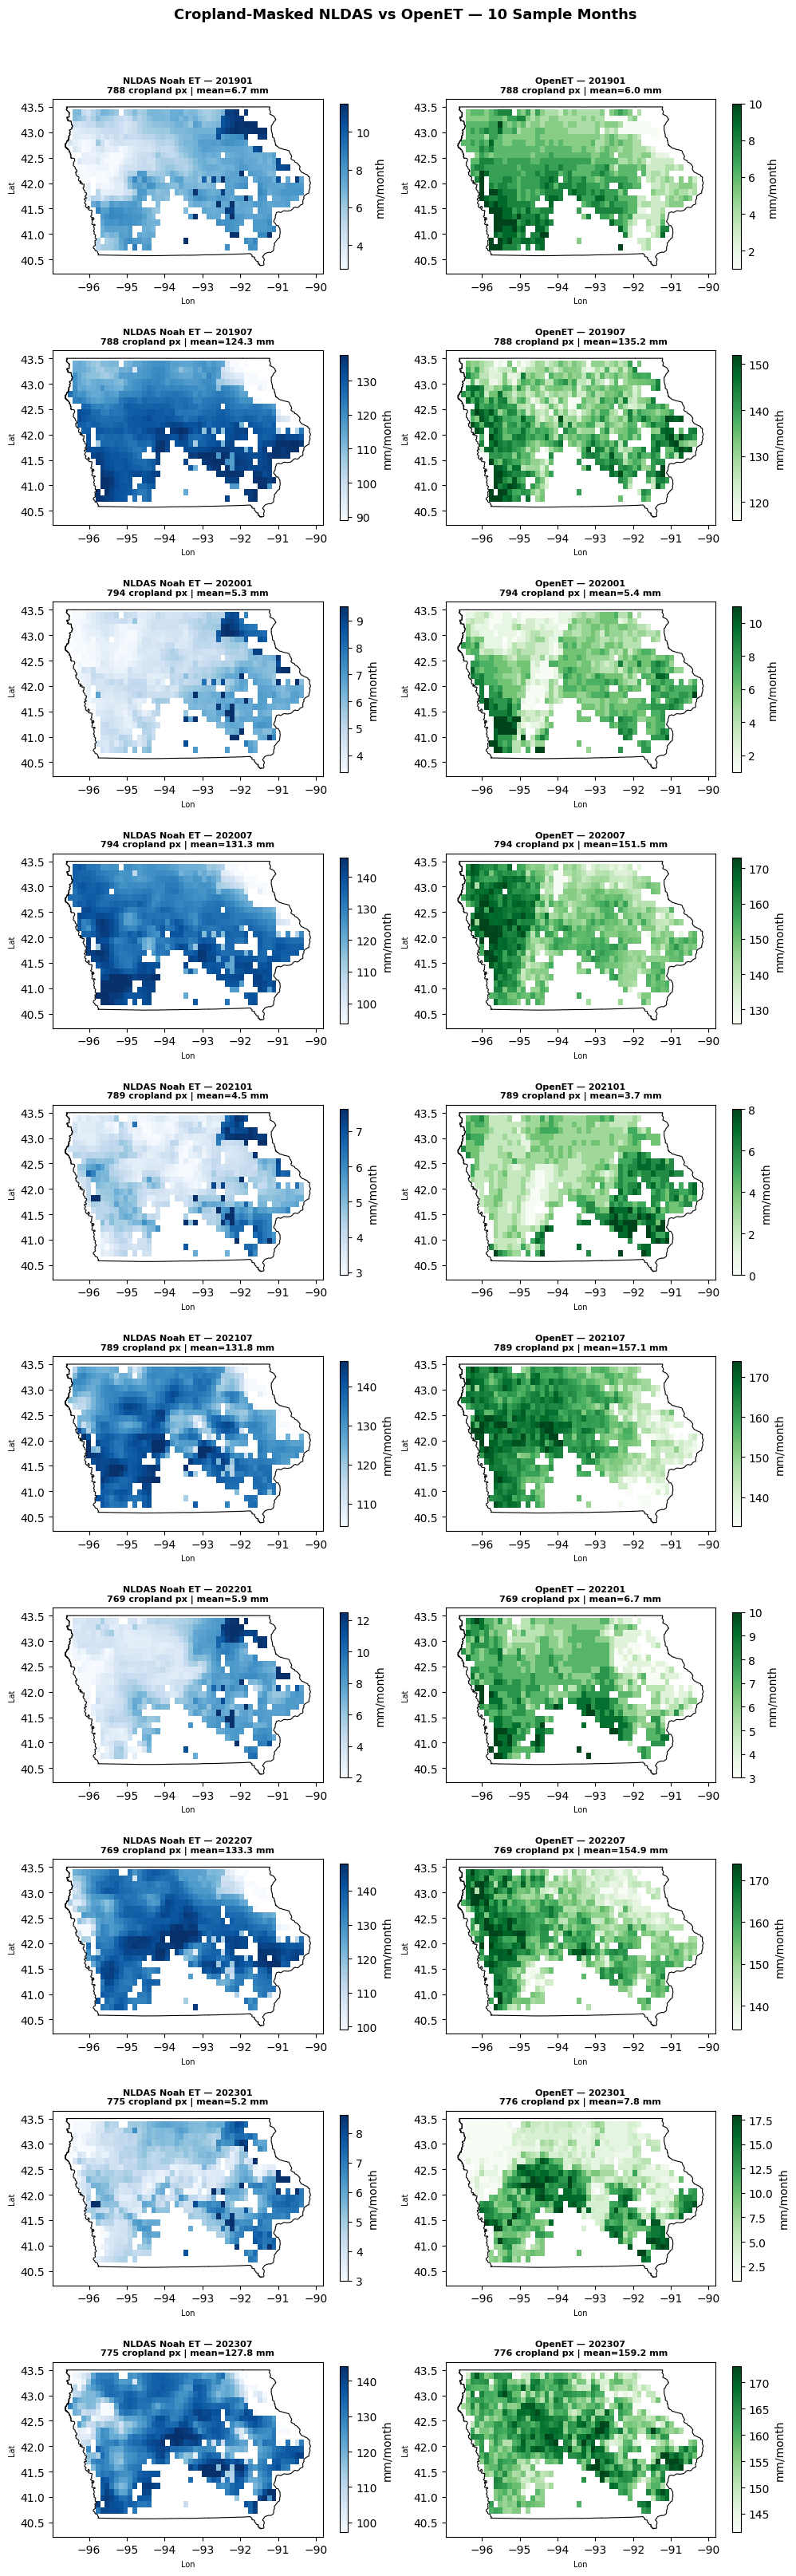

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/et_delta/masked_nldas_openet_diagnostic.png


In [10]:
# ── Side-by-side diagnostic: 10 sample months, NLDAS | OpenET ──────────────
step    = max(1, len(nldas_files) // 10)
samples = [f.name.split('.A')[1][:6] for f in nldas_files[::step][:10]]

ncols, nrows = 2, len(samples)
fig, axes = plt.subplots(nrows, ncols, figsize=(10, nrows * 3.2))

for row, yyyymm in enumerate(samples):
    year = int(yyyymm[:4])
    nldas_f  = nldas_masked_dir  / f'NLDAS_Iowa_cropland_{yyyymm}.tif'
    openet_f = openet_masked_dir / f'OpenET_Iowa_cropland_{yyyymm}.tif'

    for col, (fpath, label, cmap) in enumerate([
        (nldas_f,  'NLDAS Noah ET', 'Blues'),
        (openet_f, 'OpenET',        'Greens'),
    ]):
        ax = axes[row, col]
        if not fpath.exists():
            ax.set_title(f'{label} {yyyymm}\nFILE NOT FOUND', color='red')
            continue

        da = rxr.open_rasterio(fpath, masked=True).squeeze()
        arr = da.values.astype(float)

        valid = arr[~np.isnan(arr)]
        vmin, vmax_v = (np.nanpercentile(valid, [2, 98]) if len(valid) else (0, 1))
        if vmax_v - vmin < 1:
            vmin, vmax_v = max(0, vmin - 1), vmax_v + 1

        extent = [float(da.x.min()), float(da.x.max()),
                  float(da.y.min()), float(da.y.max())]
        im = ax.imshow(arr, extent=extent, origin='upper',
                       cmap=cmap, vmin=vmin, vmax=vmax_v, aspect='auto')
        iowa_gdf.boundary.plot(ax=ax, color='black', linewidth=0.8)
        plt.colorbar(im, ax=ax, shrink=0.8, label='mm/month')

        n_crop = int((~np.isnan(arr)).sum())
        ax.set_title(f'{label} — {yyyymm}\n{n_crop} cropland px | mean={np.nanmean(arr):.1f} mm',
                     fontsize=8, fontweight='bold')
        ax.set_xlabel('Lon', fontsize=7)
        ax.set_ylabel('Lat', fontsize=7)

plt.suptitle('Cropland-Masked NLDAS vs OpenET — 10 Sample Months',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
out_fig = figures_dir / 'masked_nldas_openet_diagnostic.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_fig}')


## 6. Save Summary CSV

Export the per-month summary statistics to a CSV file. This CSV is the primary
input for the `sif_irrigation_drought.ipynb` analysis notebook.

In [ ]:
# Save monthly summary statistics to CSV
csv_path = output_dir / 'ET_delta_monthly_summary_Iowa_cropland.csv'
df.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')

# Show the first few rows as a sanity check
print(f'\nShape: {df.shape[0]} months × {df.shape[1]} columns')
print(df.head(12).to_string(index=False))

## 7. Visualize — ΔET Time Series (Iowa Cropland Mean)

Plot the 10-year monthly time series of:
- **Top panel:** Raw OpenET and NLDAS Noah ET side-by-side — confirms the data loaded
  correctly and shows the seasonal cycle of both products.
- **Bottom panel:** ΔET = OpenET − NLDAS Noah (bars colored red for positive, blue for
  negative). The ±1 std dev shading indicates inter-pixel spread within Iowa cropland.

The **+20 mm/month threshold** (dashed line) marks the boundary between high-confidence
irrigation and measurement noise. Months where ΔET clearly exceeds this line (typically
July–August during drought years) represent the strongest irrigation signal.

In [ ]:
# ── Irrigation confidence threshold ───────────────────────────────────────────
# 20 mm/month is the approximate combined measurement uncertainty of OpenET and
# NLDAS Noah. ΔET above this threshold is considered high-confidence irrigation.
IRR_THRESHOLD_MM = 20.0

dates = pd.to_datetime(df['yyyymm'], format='%Y%m')

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# ── Top panel: OpenET vs NLDAS Noah (raw ET values) ──────────────────────────
ax = axes[0]
ax.plot(dates, df['openet_mean'], 'o-', color='steelblue', label='OpenET (actual)',
        linewidth=1.5, markersize=3)
ax.plot(dates, df['nldas_mean'],  'o-', color='darkorange', label='NLDAS Noah (modeled)',
        linewidth=1.5, markersize=3)
ax.set_ylabel('Mean ET — Iowa cropland (mm/month)', fontsize=11)
ax.set_title(f'OpenET vs NLDAS Noah ET — Iowa Cropland {YEARS[0]}–{YEARS[-1]}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Add year dividers
for year in YEARS:
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='gray', lw=0.4, ls=':', alpha=0.5)

# ── Bottom panel: ΔET bars + threshold line ───────────────────────────────────
ax = axes[1]
bar_colors = ['tomato' if v > 0 else 'steelblue' for v in df['delta_mean']]
ax.bar(dates, df['delta_mean'], width=20, color=bar_colors, alpha=0.8,
       label='Mean ΔET (OpenET − NLDAS)')
ax.axhline(0, color='black', linewidth=0.8)
ax.fill_between(dates,
                df['delta_mean'] - df['delta_std'],
                df['delta_mean'] + df['delta_std'],
                alpha=0.2, color='gray', label='±1 std dev (spatial spread)')

# High-confidence irrigation threshold
ax.axhline(IRR_THRESHOLD_MM, color='darkred', linewidth=1.5, linestyle='--',
           label=f'+{IRR_THRESHOLD_MM:.0f} mm/month — High-confidence irrigation threshold')

ax.set_ylabel('ΔET = OpenET − NLDAS Noah (mm/month)', fontsize=11)
ax.set_title(
    f'Human ET Contribution (ΔET) — Iowa Cropland\n'
    f'Red bars = Excess ET above NLDAS baseline  |  '
    f'Dashed line = {IRR_THRESHOLD_MM:.0f} mm/month confidence threshold',
    fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

for year in YEARS:
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='gray', lw=0.4, ls=':', alpha=0.5)

plt.tight_layout()
plt.savefig(figures_dir / 'et_delta_timeseries_cropland.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {figures_dir}/et_delta_timeseries_cropland.png')

## 8. Visualize — Seasonal Cycle of ΔET

Plot ΔET by calendar month with each year as a separate line, plus the 10-year mean.
The seasonal cycle reveals when human water additions are concentrated — typically
peaking in July–August when crop water demand is highest and precipitation deficits
are most common.

Note that years with strong drought (e.g., any year with elevated Drought Monitor
severity) often show higher ΔET in summer — drought triggers more irrigation pumping.

In [ ]:
# Use a qualitative colormap so each year has a visually distinct color
import matplotlib.cm as cm
year_colors = {y: cm.tab10(i % 10) for i, y in enumerate(YEARS)}

fig, ax = plt.subplots(figsize=(13, 6))

for year in YEARS:
    yr_df = df[df['year'] == year].sort_values('month')
    if not yr_df.empty:
        ax.plot(yr_df['month'], yr_df['delta_mean'], 'o-',
                color=year_colors[year], linewidth=2, markersize=5, label=str(year))

# Multi-year mean seasonal cycle (across all available years)
monthly_mean = df.groupby('month')['delta_mean'].mean()
ax.plot(monthly_mean.index, monthly_mean.values, 'k--',
        linewidth=3, markersize=8, label=f'{len(YEARS)}-yr mean', zorder=5)

# Mark the high-confidence irrigation threshold
ax.axhline(IRR_THRESHOLD_MM, color='darkred', linewidth=1.5, linestyle='--',
           alpha=0.7, label=f'+{IRR_THRESHOLD_MM:.0f} mm — High-confidence irrigation')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('ΔET (mm/month)', fontsize=12)
ax.set_title(f'Seasonal Cycle of Human ET Contribution — Iowa Cropland {YEARS[0]}–{YEARS[-1]}\n'
             f'ΔET = OpenET − NLDAS Noah  |  Each line = one year',
             fontsize=13, fontweight='bold')
ax.legend(title='Year', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'et_delta_seasonal_cycle_cropland.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {figures_dir}/et_delta_seasonal_cycle_cropland.png')

## 9. Visualize — Spatial Maps of ΔET

Map the ΔET spatial pattern for a sample year across the growing season (April–October).
Red = excess ET (irrigation); blue = ET deficit (drought stress or fallow).
Grey areas are non-cropland pixels that have been masked out.

Change `sample_year` to view any year in the study period.

In [ ]:
# ── Select sample year and months to map ─────────────────────────────────────
# Change sample_year to any year in YEARS to view a different year's spatial patterns
sample_year  = max(YEARS)   # defaults to most recent year with data
plot_months  = [4, 5, 6, 7, 8, 9, 10]   # April–October (growing season)
month_names  = {4:'April',5:'May',6:'June',7:'July',8:'August',9:'September',10:'October'}

# Check which months are actually available for the sample year
available    = [(y, m) for (y, m) in delta_grids if y == sample_year and m in plot_months]
plot_months  = sorted([m for (_, m) in available])

if not plot_months:
    print(f'No delta grids available for {sample_year} — run Section 5 first.')
else:
    fig, axes = plt.subplots(1, len(plot_months), figsize=(3.5 * len(plot_months), 5))

    # Use a symmetric color scale centered on 0 based on the 95th percentile of |ΔET|
    all_vals = np.concatenate([
        delta_grids[(sample_year, m)].values.flatten()
        for m in plot_months if (sample_year, m) in delta_grids
    ])
    vmax = np.nanpercentile(np.abs(all_vals[~np.isnan(all_vals)]), 95)
    # Ensure the threshold line is always visible in the colorscale
    vmax = max(vmax, IRR_THRESHOLD_MM * 1.5)
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    for ax, month in zip(np.array(axes).flatten(), plot_months):
        if (sample_year, month) not in delta_grids:
            ax.set_visible(False)
            continue

        data = delta_grids[(sample_year, month)]
        im = ax.imshow(
            data.values,
            extent=[float(data.x.min()), float(data.x.max()),
                    float(data.y.min()), float(data.y.max())],
            origin='upper', cmap='RdBu_r', norm=norm
        )
        iowa_gdf.boundary.plot(ax=ax, color='black', linewidth=0.8)
        mean_val = float(np.nanmean(data.values))
        ax.set_title(f'{month_names.get(month, month)} {sample_year}\n'
                     f'Δ={mean_val:+.1f} mm', fontsize=10, fontweight='bold')
        ax.set_xlabel('Longitude', fontsize=8)
        ax.set_ylabel('Latitude', fontsize=8)

    cbar = fig.colorbar(im, ax=np.array(axes).flatten(), orientation='horizontal',
                        fraction=0.03, pad=0.12)
    cbar.set_label('ΔET = OpenET − NLDAS Noah (mm/month)  |  '
                   'Red = irrigation signal  |  Grey = non-cropland', fontsize=9)

    plt.suptitle(f'Human ET Contribution — Iowa Cropland {sample_year}\n'
                 f'(growing season April–October)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    fig_name = f'et_delta_maps_{sample_year}_cropland.png'
    plt.savefig(figures_dir / fig_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {figures_dir}/{fig_name}')

## 10. Visualize — Annual × Monthly ΔET Heatmap

A compact 10-year view: rows = years, columns = months. Color encodes the mean ΔET
across Iowa cropland pixels. Annotated with numeric values so the strongest irrigation
signals (large positive values in summer drought years) are easy to identify at a glance.

The dashed contour at ΔET = +20 mm/month marks the irrigation confidence threshold.

In [ ]:
# Pivot to (year × month) matrix
pivot = df.pivot(index='year', columns='month', values='delta_mean')

# Symmetric colorscale centered on 0
vmax = np.nanpercentile(np.abs(pivot.values[~np.isnan(pivot.values)]), 95)
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, ax = plt.subplots(figsize=(15, max(4, len(pivot) * 0.5 + 1)))
im = ax.imshow(pivot.values, cmap='RdBu_r', norm=norm, aspect='auto')

# Annotate cells with rounded ΔET values
for i in range(len(pivot.index)):
    for j in range(12):
        val = pivot.values[i, j]
        if not np.isnan(val):
            txt_color = 'white' if abs(val) > vmax * 0.55 else 'black'
            # Mark high-confidence irrigation months with bold font
            weight = 'bold' if val > IRR_THRESHOLD_MM else 'normal'
            ax.text(j, i, f'{val:+.0f}', ha='center', va='center', fontsize=8,
                    color=txt_color, fontweight=weight)

# Draw a dashed contour at the irrigation threshold
filled = np.where(np.isnan(pivot.values), 0.0, pivot.values)
cs = ax.contour(filled, levels=[IRR_THRESHOLD_MM], colors='darkred',
                linewidths=2, linestyles='--')
ax.clabel(cs, fmt=f'ΔET = +{IRR_THRESHOLD_MM:.0f} mm', fontsize=8, inline=True)

ax.set_xticks(range(12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Year', fontsize=11)
ax.set_title(
    f'ΔET Heatmap — Iowa Cropland {YEARS[0]}–{YEARS[-1]}\n'
    f'Red = High irrigation signal  |  Bold values exceed {IRR_THRESHOLD_MM:.0f} mm/month threshold',
    fontsize=13, fontweight='bold'
)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Mean ΔET (mm/month)', fontsize=10)

plt.tight_layout()
plt.savefig(figures_dir / 'et_delta_heatmap_cropland.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {figures_dir}/et_delta_heatmap_cropland.png')

## 11. Summary

Print a final summary of the 10-year ΔET analysis including:
- Overall statistics
- Annual totals and classification of high-confidence vs low-confidence irrigation months
- Peak months when irrigation signal exceeds the 20 mm/month threshold

In [ ]:
month_names_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                   7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

print('=' * 70)
print(f'ET Harmonization Summary — Iowa Cropland {YEARS[0]}–{YEARS[-1]}')
print('=' * 70)
print(f'Cropland fraction threshold:       {CROPLAND_FRACTION_THRESHOLD}')
print(f'Months processed:                  {len(df)}')
print(f'Months skipped (missing data):     {len(skipped)}')
print(f'High-confidence irrigation threshold: {IRR_THRESHOLD_MM} mm/month')
print()
print(f'Mean cropland pixels per month:    {df["n_crop_pixels"].mean():.0f}')
print(f'Overall mean OpenET (cropland):    {df["openet_mean"].mean():.1f} mm/month')
print(f'Overall mean NLDAS  (cropland):    {df["nldas_mean"].mean():.1f} mm/month')
print(f'Overall mean ΔET    (cropland):    {df["delta_mean"].mean():+.1f} mm/month')
print()

# Count months above vs below the irrigation threshold
hi_irr = (df['delta_mean'] > IRR_THRESHOLD_MM).sum()
lo_irr = (df['delta_mean'] <= IRR_THRESHOLD_MM).sum()
print(f'High-confidence irrigation months (ΔET > {IRR_THRESHOLD_MM} mm): {hi_irr}')
print(f'Low-confidence / no irrigation months:                          {lo_irr}')
print()

print(f'Annual mean ΔET (Iowa cropland pixels):')
for year, grp in df.groupby('year'):
    n_hi = (grp['delta_mean'] > IRR_THRESHOLD_MM).sum()
    print(f'  {year}: {grp["delta_mean"].mean():+.1f} mm/month  '
          f'(annual sum: {grp["delta_mean"].sum():+.0f} mm/yr)  '
          f'| {n_hi} high-confidence irrigation months')
print()

print('Peak months (highest 10-yr mean ΔET):')
top = df.groupby('month')['delta_mean'].mean().sort_values(ascending=False).head(4)
for m, v in top.items():
    label = "HIGH CONF" if v > IRR_THRESHOLD_MM else "low conf"
    print(f'  {month_names_map[m]}: {v:+.1f} mm/month  [{label}]')

print()
print(f'Output GeoTIFFs:   {output_dir}')
print(f'Summary CSV:       {csv_path}')
print(f'Figures:           {figures_dir}')